# SVM with hinge loss and subdifferential descent

import numpy as np
import matplotlib.pyplot as plt

# --------------------- 1. Генерация данных ---------------------

np.random.seed(42)
N = 100  # число объектов
X1 = np.random.randn(N//2, 2) + np.array([2, 2])   # смещаем один класс
X2 = np.random.randn(N//2, 2) + np.array([-2, -2]) # смещаем другой класс

X = np.vstack([X1, X2])          # матрица объекты x признаки
y = np.hstack([np.ones(N//2), -np.ones(N//2)])  # метки классов: +1, -1

# Перемешаем всё вместе для наглядности
perm = np.random.permutation(N)
X = X[perm]
y = y[perm]

# --------------------- 2. Функция потерь (объектив) ---------------------

def hinge_svm_objective(w, X, y, lambd):
    """
    Возвращает значение функционала:
      L(w) = (lambda/2)*||w||^2 + (1/N)*sum( max(0, 1 - y_i * w^T x_i) ).
    """
    # Считаем суммарное значение hinge loss по всем объектам
    margins = 1 - y * (X.dot(w))
    hinge_losses = np.maximum(0, margins)
    return (lambd/2)*np.sum(w**2) + np.mean(hinge_losses)

# --------------------- 3. Субградиент функционала ---------------------

def hinge_svm_subgradient(w, X, y, lambd):
    """
    Возвращает субградиент g(w) для функционала:
      g(w) = lambda*w + (1/N)*sum( -y_i*x_i, если y_i*w^T x_i < 1 ).
    """
    N = X.shape[0]
    margins = 1 - y * (X.dot(w))
    
    # Определяем, где слагаемое активно (hinge > 0)
    active_mask = (margins > 0).astype(float)
    
    # Считаем суммарный "градиент" для hinge-части
    # Для тех i, где margin>0, добавляем -y_i*x_i
    grad_hinge = -(y * active_mask)[:, np.newaxis] * X
    
    # Усреднение по N
    grad_hinge = grad_hinge.mean(axis=0)
    
    # Итоговый субградиент
    g = lambd * w + grad_hinge
    return g

# --------------------- 4. Субградиентный спуск ---------------------

def subgradient_descent(
    X, y, lambd=0.01, 
    max_iter=100, 
    step_rule='constant', 
    c=1.0
):
    """
    Субградиентный спуск для SVM с hinge loss:
      L(w) = (lambda/2)*||w||^2 + ...
    
    Параметры:
      X, y     : выборка
      lambd    : коэффициент регуляризации
      max_iter : число итераций
      step_rule: стратегия выбора шага ('constant', '1_over_k', '1_over_sqrt_k')
      c        : константа для шага
    
    Возвращает:
      w_history  : список векторов w на каждой итерации
      loss_history: список значений функционала L(w) на каждой итерации
    """
    w = np.zeros(X.shape[1])
    w_history = [w.copy()]
    loss_history = [hinge_svm_objective(w, X, y, lambd)]
    
    for k in range(1, max_iter+1):
        g = hinge_svm_subgradient(w, X, y, lambd)
        
        # Выбираем шаг в зависимости от стратегии
        if step_rule == 'constant':
            alpha = c
        elif step_rule == '1_over_k':
            alpha = c / k
        elif step_rule == '1_over_sqrt_k':
            alpha = c / np.sqrt(k)
        else:
            raise ValueError("Неизвестная стратегия шага")
        
        w = w - alpha * g
        
        w_history.append(w.copy())
        loss_history.append(hinge_svm_objective(w, X, y, lambd))
    
    return w_history, loss_history

# --------------------- 5. Запуск эксперимента ---------------------

max_iter = 50
lambd = 0.01
c = 1.0

strategies = ['constant', '1_over_k', '1_over_sqrt_k']
results = {}

for s in strategies:
    w_hist, loss_hist = subgradient_descent(
        X, y, lambd=lambd, max_iter=max_iter, step_rule=s, c=c
    )
    results[s] = (w_hist, loss_hist)

# --------------------- 6. Графики ---------------------

# (a) Изменение значения функционала
plt.figure()
for s in strategies:
    loss_hist = results[s][1]
    plt.plot(loss_hist, label=f"Шаг: {s}")
plt.xlabel("Номер итерации")
plt.ylabel("L(w)")
plt.title("Сравнение субградиентного спуска\nSVM с hinge loss: значение функционала")
plt.legend()
plt.show()

# (b) Разделяющие прямые для каждого подхода
#
# Для 2D-признаков разделяющая гиперплоскость задаётся уравнением:
#   w0*x + w1*y = 0  =>  y = -(w0/w1)*x
#
# Построим ее на сетке для финальных w каждого подхода.

plt.figure()
# Рисуем выборку
plt.scatter(X[y==1, 0], X[y==1, 1], label="Класс +1")
plt.scatter(X[y==-1, 0], X[y==-1, 1], label="Класс -1")

# Координаты для отрисовки прямых
x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)

for s in strategies:
    w_final = results[s][0][-1]  # последний w
    # Если w1=0, то разделяющая "прямая" вертикальна. Проверим на всякий случай:
    if abs(w_final[1]) < 1e-10:
        # x = const
        x_const = -0.0 if abs(w_final[0])<1e-10 else 0.0
        # Если w_final[0] != 0, то уравнение w0*x + w1*y=0 => x=0.
        plt.plot([x_const, x_const], [X[:,1].min()-1, X[:,1].max()+1], 
                 label=f"Реш. прямая ({s})")
    else:
        y_vals = -(w_final[0]/w_final[1]) * x_vals
        plt.plot(x_vals, y_vals, label=f"Реш. прямая ({s})")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Разделяющие прямые после 50 итераций субградиентного спуска")
plt.legend()
plt.show()


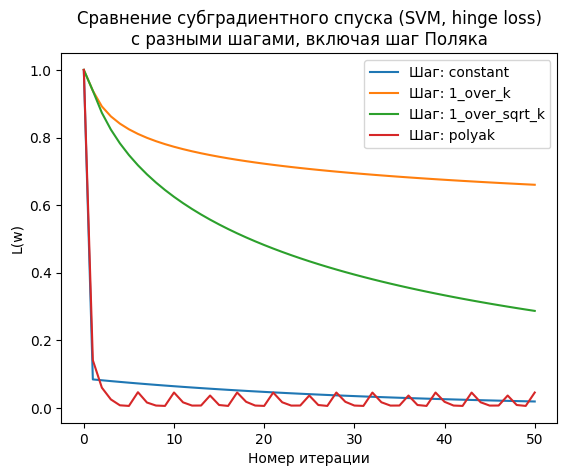

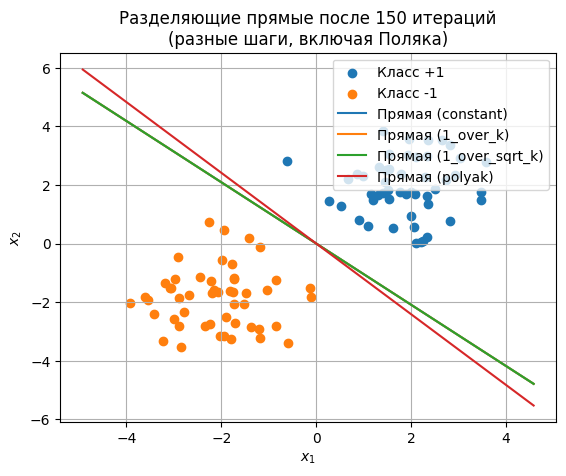

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------- 1. Генерация данных ---------------------

np.random.seed(42)
N = 100  # число объектов
X1 = np.random.randn(N//2, 2) + np.array([2, 2])   # смещаем один класс
X2 = np.random.randn(N//2, 2) + np.array([-2, -2]) # смещаем другой класс

X = np.vstack([X1, X2])          # матрица объекты x признаки
y = np.hstack([np.ones(N//2), -np.ones(N//2)])  # метки классов: +1, -1

# Перемешаем всё вместе для наглядности
perm = np.random.permutation(N)
X = X[perm]
y = y[perm]

# --------------------- 2. Функция потерь (объектив) ---------------------

def hinge_svm_objective(w, X, y, lambd):
    """
    Возвращает значение функционала:
      L(w) = (lambda/2)*||w||^2 + (1/N)*sum( max(0, 1 - y_i * w^T x_i) ).
    """
    margins = 1 - y * (X.dot(w))
    hinge_losses = np.maximum(0, margins)
    return (lambd/2)*np.sum(w**2) + np.mean(hinge_losses)

# --------------------- 3. Субградиент функционала ---------------------

def hinge_svm_subgradient(w, X, y, lambd):
    """
    Возвращает субградиент g(w) для:
      g(w) = lambda*w + (1/N)*sum( -y_i*x_i, если y_i*w^T x_i < 1 ).
    """
    N = X.shape[0]
    margins = 1 - y * (X.dot(w))
    active_mask = (margins > 0).astype(float)  # где hinge>0
    
    # Суммируем -y_i*x_i по всем активным (margin>0)
    grad_hinge = -(y * active_mask)[:, np.newaxis] * X
    grad_hinge = grad_hinge.mean(axis=0)
    
    g = lambd*w + grad_hinge
    return g

# --------------------- 4. Субградиентный спуск ---------------------

def subgradient_descent(
    X, y, lambd=0.01, 
    max_iter=150, 
    step_rule='constant', 
    c=1.0,
    f_star=0.0
):
    """
    Субградиентный спуск для SVM с hinge loss:
    
    Параметры:
      X, y       : выборка
      lambd      : коэффициент регуляризации
      max_iter   : число итераций
      step_rule  : стратегия выбора шага:
                     - 'constant'       -> alpha_k = c
                     - '1_over_k'       -> alpha_k = c/k
                     - '1_over_sqrt_k'  -> alpha_k = c/sqrt(k)
                     - 'polyak'         -> alpha_k = (f(w_k) - f_star)/||g_k||^2
      c          : константа для шага (используется во всех, кроме 'polyak')
      f_star     : предполагаемый минимум (для 'polyak')
    
    Возвращает:
      w_history   : список векторов w на каждой итерации
      loss_history: список значений функционала L(w) на каждой итерации
    """
    w = np.zeros(X.shape[1])
    w_history = [w.copy()]
    loss_history = [hinge_svm_objective(w, X, y, lambd)]
    
    for k in range(1, max_iter+1):
        g = hinge_svm_subgradient(w, X, y, lambd)
        loss_current = hinge_svm_objective(w, X, y, lambd)
        
        # Выбираем шаг
        if step_rule == 'constant':
            alpha = c
        elif step_rule == '1_over_k':
            alpha = c / k
        elif step_rule == '1_over_sqrt_k':
            alpha = c / np.sqrt(k)
        elif step_rule == 'polyak':
            # Поляковский шаг: (f(w) - f_star) / ||g||^2 (с отсечением снизу нулём)
            denom = np.dot(g, g)
            if denom < 1e-15:
                alpha = 0.0
            else:
                alpha = (loss_current - f_star) / denom
                alpha = max(alpha, 0.0)  # чтобы шаг не был отрицательным
        else:
            raise ValueError("Неизвестная стратегия шага")
        
        # Обновление w
        w = w - alpha*g
        
        w_history.append(w.copy())
        loss_history.append(hinge_svm_objective(w, X, y, lambd))
    
    return w_history, loss_history

# --------------------- 5. Запуск эксперимента для разных правил шага ---------------------

max_iter = 50
lambd = 0.01

# Для примера Polyak step будем считать f^*=0 (упрощение для демонстрации).
f_star_demo = 0.0

strategies = {
    'constant':         1.5,   # константный шаг
    '1_over_k':         5.0,   # c для 1/k
    '1_over_sqrt_k':    5.0,   # c для 1/sqrt(k)
    'polyak':           None   # для Polyak шаг c не используется
}

results = {}
for rule, c_val in strategies.items():
    w_hist, loss_hist = subgradient_descent(
        X, y, lambd=lambd, max_iter=max_iter,
        step_rule=rule,
        c=c_val if c_val is not None else 1.0,  # заглушка
        f_star=f_star_demo
    )
    results[rule] = (w_hist, loss_hist)

# --------------------- 6. Графики ---------------------

# (a) Изменение значения функционала
plt.figure()
for rule in strategies.keys():
    loss_hist = results[rule][1]
    plt.plot(loss_hist, label=f"Шаг: {rule}")
plt.xlabel("Номер итерации")
plt.ylabel("L(w)")
plt.title("Сравнение субградиентного спуска (SVM, hinge loss)\nс разными шагами, включая шаг Поляка")
plt.legend()
plt.show()

# (b) Финальные разделяющие прямые
plt.figure()
plt.scatter(X[y==1, 0], X[y==1, 1], label="Класс +1")
plt.scatter(X[y==-1, 0], X[y==-1, 1], label="Класс -1")

x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
for rule in strategies.keys():
    w_final = results[rule][0][-1]  # последний w
    if abs(w_final[1]) < 1e-15:
        # Вертикальная прямая
        x_const = -0.0
        plt.plot([x_const, x_const], [X[:,1].min()-1, X[:,1].max()+1],
                 label=f"Прямая ({rule})")
    else:
        y_vals = -(w_final[0]/w_final[1]) * x_vals
        plt.plot(x_vals, y_vals, label=f"Прямая ({rule})")

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Разделяющие прямые после 150 итераций\n(разные шаги, включая Поляка)")
plt.legend()
plt.grid(True)
plt.show()